In [1]:
import numpy as np
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
fn = '/global/homes/l/linyaoly/ERA5/reanalysis/ROMI_calculation_20241214/romi.1x.txt'
col = ['year','month','day','time','romi1','romi2','amp']
real_romi = pd.read_fwf(fn, header=None,widths=[5, 2,3, 3, 13, 12, 11], names=col)

In [4]:
fnw = '/global/homes/l/linyaoly/ERA5/reanalysis/ROMI_calculation_20241214/romi_wsg.txt'
col = ['year','month','day','romi1','romi2','pha']
wsg_romi = pd.read_fwf(fnw, header=None,widths=[5,5,5,11,11,3], names=col)

y_romi_old = xr.open_dataset('/global/homes/l/linyaoly/ERA5/reanalysis/ROMI_calculation_20241214/ROMI_ERA5_daily_1979to2014.nc')
y_romi = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/ROMI_cal/ROMI_ERA5_daily_1979to2012.nc')

In [5]:
y_romi 

<xarray.Dataset>
Dimensions:  (time: 16847, mode: 2)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2025-02-14
  * mode     (mode) int64 0 1
Data variables:
    ROMI     (time, mode) float64 ...

In [11]:
rmm = xr.open_dataarray('/pscratch/sd/l/linyaoly/ERA5/reanalysis/rmm/full/RMM_ERA5_daily_1979to2012.nc')

In [12]:
rmm_new = xr.open_dataarray('/pscratch/sd/l/linyaoly/ERA5/reanalysis/rmm/RMM_ERA5_daily_1979to2012.nc')

In [13]:
# correlation: 
pc = rmm_new.sel(time=slice('1979-01-01','2021-02-20'))
pc_old = rmm.sel(time=slice('1979-01-01','2021-02-20'))

a = np.sum(pc[:,0].values * pc_old[:,0].values + pc[:,1].values * pc_old[:,1].values)
b = np.sqrt(np.sum(pc[:,0].values**2 + pc[:,1].values**2) * np.sum(pc_old[:,0].values**2 + pc_old[:,1].values**2))

r = a/b
r

0.995857815288727

In [6]:
# correlation: 
pc = y_romi['ROMI'].sel(time=slice('1979-01-01','2021-02-20'))
pc_old = y_romi_old['ROMI'].sel(time=slice('1979-01-01','2021-02-20'))

a = np.sum(pc[:,0].values * pc_old[:,0].values + pc[:,1].values * pc_old[:,1].values)
b = np.sqrt(np.sum(pc[:,0].values**2 + pc[:,1].values**2) * np.sum(pc_old[:,0].values**2 + pc_old[:,1].values**2))

r = a/b
r

0.9989446205704144

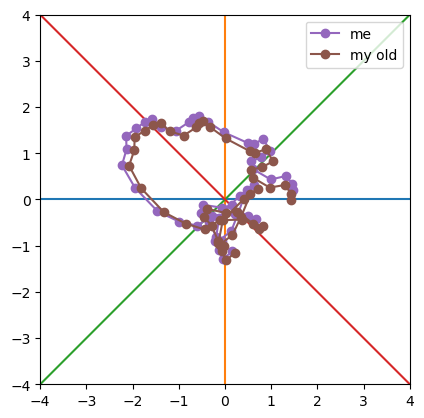

In [14]:
stp = 50

pc = rmm_new.sel(time=slice('2002-01-01','2002-02-20'))
pc_old = rmm.sel(time=slice('2002-01-01','2002-02-20'))
pc1plt = pc[:,1]
pc2plt = -pc[:,0]

pc1plt_old = pc_old[:,1]    
pc2plt_old = -pc_old[:,0]

# # draw background
fig, ax = plt.subplots()

# plt.title('MJO phase, lead='+flg+' day',fontsize=12)
x1 = np.zeros((100))
x2 = np.linspace(-4, 4, 100)

plt.plot(x2, x1)
plt.plot(x1, x2)
plt.plot(x2, x2)
plt.plot(x2, -x2)
# circ = plt.Circle((0,0), 1, edgecolor='black', facecolor='white', fill= True)
# ax.add_patch(circ)
# plt.title('MJO phase',fontsize=12)
plt.xlim([-4, 4])
plt.ylim([-4, 4])

ax.set_aspect('equal',adjustable='box')
# ax2.set_aspect('equal')

plt.plot(pc1plt,pc2plt, 'o-',label='me')
plt.plot(pc1plt_old,pc2plt_old, 'o-',label='my old')
# plt.show()
plt.legend()
# plt.savefig('MJOphaseplot_6v1tstp_dailyinput_mem3d_lead'+flg+'.png')


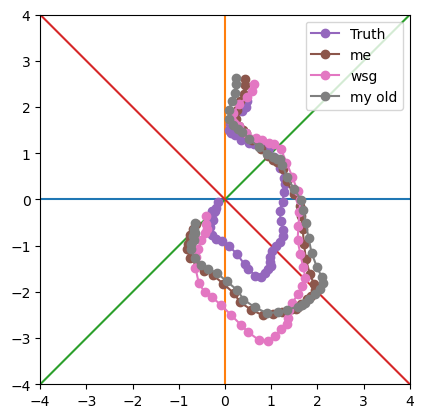

In [7]:
stp = 50
pc1plto = real_romi['romi2'][0:stp]
pc2plto = -real_romi.romi1[0:stp]
pc1plt1 = wsg_romi['romi2'][8401:stp+8401]
pc2plt2 = -wsg_romi.romi1[8401:8401+stp]
pc = y_romi['ROMI'].sel(time=slice('2002-01-01','2002-02-20'))
pc_old = y_romi_old['ROMI'].sel(time=slice('2002-01-01','2002-02-20'))
pc1plt = pc[:,1]
pc2plt = -pc[:,0]

pc1plt_old = pc_old[:,1]    
pc2plt_old = -pc_old[:,0]

# # draw background
fig, ax = plt.subplots()

# plt.title('MJO phase, lead='+flg+' day',fontsize=12)
x1 = np.zeros((100))
x2 = np.linspace(-4, 4, 100)

plt.plot(x2, x1)
plt.plot(x1, x2)
plt.plot(x2, x2)
plt.plot(x2, -x2)
# circ = plt.Circle((0,0), 1, edgecolor='black', facecolor='white', fill= True)
# ax.add_patch(circ)
# plt.title('MJO phase',fontsize=12)
plt.xlim([-4, 4])
plt.ylim([-4, 4])

ax.set_aspect('equal',adjustable='box')
# ax2.set_aspect('equal')

plt.plot(pc1plto,pc2plto, 'o-',label='Truth')
plt.plot(pc1plt,pc2plt, 'o-',label='me')
plt.plot(pc1plt1,pc2plt2, 'o-',label='wsg')
plt.plot(pc1plt_old,pc2plt_old, 'o-',label='my old')
# plt.show()
plt.legend()
# plt.savefig('MJOphaseplot_6v1tstp_dailyinput_mem3d_lead'+flg+'.png')


In [46]:
fn = '/global/homes/l/linyaoly/ERA5/reanalysis/cal_ROMI/ROMI_daily_ERA5_1979to2022.txt'
col = ['year','month','day','romi1','romi2','phase']
romi = pd.read_fwf(fnw, header=None,widths=[5,5,5,11,11,3], names=col)
romi 

,year,month,day,romi1,romi2,phase
0,1979,1,1,0.00,0.00,5
1,1979,1,2,0.00,0.00,5
2,1979,1,3,0.00,0.00,5
3,1979,1,4,0.00,0.00,5
4,1979,1,5,0.00,0.00,5
...,...,...,...,...,...,...
14915,2019,11,2,-2.15,0.43,6
14916,2019,11,3,-2.38,0.46,6
14917,2019,11,4,-2.64,0.53,6
14918,2019,11,5,-2.78,0.56,6


In [2]:
fn = '/global/homes/l/linyaoly/ERA5/reanalysis/cal_ROMI/ROMI_ERA5_daily_1979to2021.nc'
ds = xr.open_dataset(fn)
ds

<xarray.Dataset>
Dimensions:  (time: 15706, mode: 2)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2021-12-31
  * mode     (mode) int64 0 1
Data variables:
    ROMI     (time, mode) float64 ...
    phase    (time) int64 ...

In [3]:
ds['ROMI'][:100,0]

<xarray.DataArray 'ROMI' (time: 100)>
array([-1.442637, -1.554291, -1.599402, -1.610348, -1.658708, -1.710924,
       -1.745971, -1.659217, -1.576199, -1.441028, -1.259625, -1.103609,
       -1.016184, -0.940715, -0.85281 , -0.709127, -0.587347, -0.4035  ,
       -0.215696, -0.031594,  0.127632,  0.347763,  0.608797,  0.851154,
        0.989038,  1.023866,  1.021324,  0.997767,  0.911485,  0.843813,
        0.78424 ,  0.746166,  0.798204,  0.872632,  0.996493,  1.095653,
        1.140173,  1.209935,  1.276189,  1.338753,  1.328895,  1.241427,
        1.178199,  1.123256,  1.044116,  1.001492,  0.926535,  0.887117,
        0.770389,  0.690753,  0.586636,  0.451517,  0.324366,  0.213359,
        0.062934, -0.09605 , -0.325136, -0.502043, -0.604752, -0.606788,
       -0.608264, -0.608823, -0.65384 , -0.690126, -0.644067, -0.615788,
       -0.633421, -0.711966, -0.847628, -1.024706, -1.138874, -1.180567,
       -1.202465, -1.285683, -1.333754, -1.319588, -1.240279, -1.09943 ,
       -0.906704, -0.715973, -0.524024, -0.372489, -0.235133, -0.074113,
        0.057468,  0.204569,  0.409313,  0.628396,  0.820235,  0.953728,
        1.030717,  1.1054  ,  1.157866,  1.194948,  1.156515,  1.036115,
        0.903663,  0.738681,  0.530912,  0.318229])
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 1979-04-10
    mode     int64 0
Attributes:
    description:  ROMI